In [21]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [16]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [ ]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [ ]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorías que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorías presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    
    print(f"Frecuencias de cada categoría en la variable '{columna}':\n{freq_tabla}\n")

In [ ]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal') # Asegura que el gráfico sea circular

In [22]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [27]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [23]:
penguins_df = pd.read_csv('penguins_lter.csv')

In [3]:
print(f"Dimensiones del dataset original: {penguins_df.shape}")
penguins_df.head()

Dimensiones del dataset original: (344, 17)


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


In [ ]:
print("Tipos de Variables y Datos Nulos")
penguins_df.info()

Tipos de Variables y Datos Nulos
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo) 

In [ ]:
print("Estadística Descriptiva")
penguins_df.describe()

Estadística Descriptiva


,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [6]:
#Estadística básica + percentiles
display(penguins_df.describe(percentiles=[.1, .9, .95]))

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
10%,12.000000,36.600000,14.300000,185.000000,3300.000000,8.047194,-26.688670
90%,121.000000,50.800000,19.500000,220.900000,5400.000000,9.491237,-24.528960
95%,134.850000,51.995000,20.000000,225.000000,5650.000000,9.689424,-24.361660
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


In [ ]:
#Estadística avanzada con SciPy
cols_numericas = ['Sample Number', 'Culmen Length', 'Culmen Depth', 'Flipper Length', 'Body Mass', 'Delta 15 N', 'Delta 13 C'] 
columnas_datos = [
    'Sample Number',
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)',
    'Delta 15 N (o/oo)',
    'Delta 13 C (o/oo)'
]

ed_penguins = st.describe(penguins_df[columnas_datos].dropna())

ed_penguins_df = pd.DataFrame({ 
    'Observaciones': ed_penguins.nobs,
    'Min': ed_penguins.minmax[0],
    'Max': ed_penguins.minmax[1],
    'Media': ed_penguins.mean,
    'Varianza': ed_penguins.variance,
    'Asimetría': ed_penguins.skewness,
    'Curtosis': ed_penguins.kurtosis
}, index=cols_numericas)

print("\nEstadística descriptiva avanzada con SciPy:")
display(ed_penguins_df)


Estadística descriptiva avanzada con SciPy:


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
Sample Number,330,1.00000,152.00000,64.442424,1624.040748,0.317083,-0.943427
Culmen Length,330,32.10000,59.60000,44.047273,29.668458,0.018001,-0.861355
Culmen Depth,330,13.10000,21.50000,17.105455,3.914985,-0.116643,-0.936231
Flipper Length,330,172.00000,231.00000,201.312121,194.950916,0.326102,-0.991685
Body Mass,330,2700.00000,6300.00000,4215.833333,648264.880952,0.444074,-0.752142
Delta 15 N,330,7.63220,10.02544,8.733382,0.304451,0.237893,-0.754918
Delta 13 C,330,-27.01854,-23.89017,-25.692045,0.621301,0.324076,-1.062462


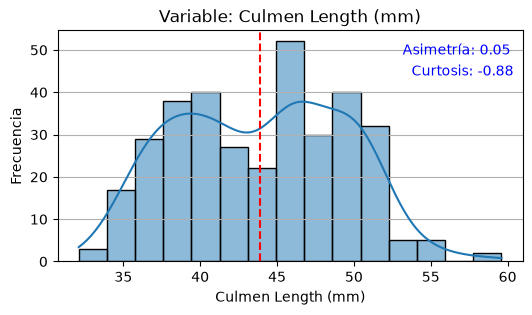

In [18]:
# Histograma para analizar la longitud del pico
plot_histograma(penguins_df, 'Culmen Length (mm)', mvd= False, snk=True)


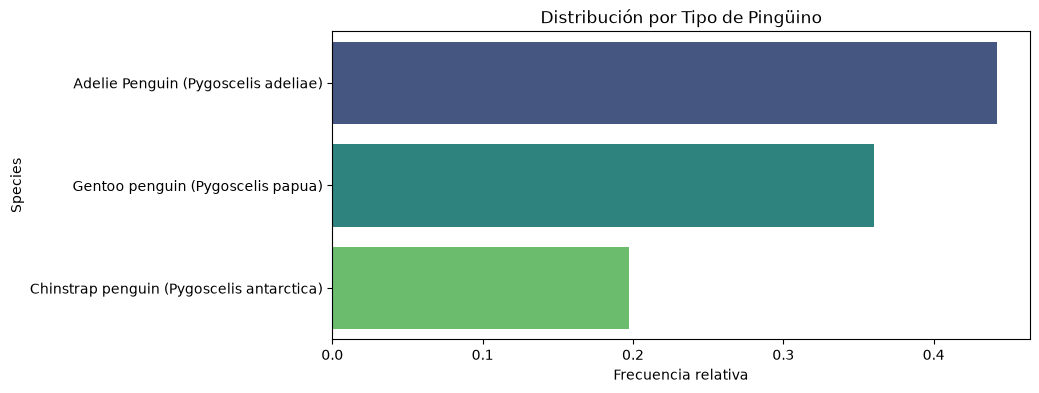

In [24]:
# Frecuencia relativa para ver cuántos tipos de pingüinos hay y de qué tipo hay más o menos
plot_frecuencias_relativas(penguins_df, 'Species', title='Distribución por Tipo de Pingüino')

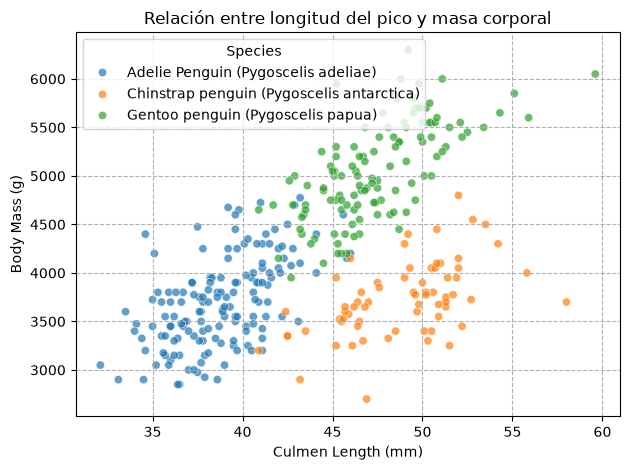

In [ ]:
# Relaciones entre variables (Numérica-Numérica: Scatterplot)
sns.scatterplot(data=penguins_df, x='Culmen Length (mm)', y='Body Mass (g)', hue='Species', alpha=0.7) 
plt.grid(ls='--') 
plt.title('Relación entre longitud del pico y masa corporal')
plt.tight_layout() 
plt.show() 

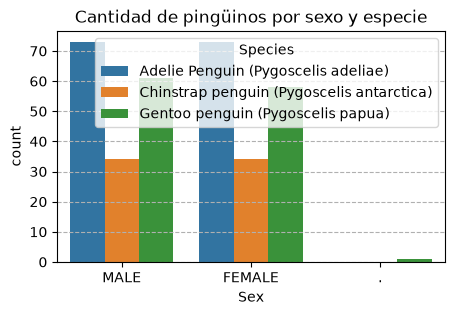

In [29]:
# Cuántos pingüinos hay de cada sexo según la especie?
plt.figure(figsize=(5, 3))
sns.countplot(x='Sex', hue='Species', data=penguins_df)
plt.grid(ls='--', axis='y')
plt.title("Cantidad de pingüinos por sexo y especie")
plt.show()

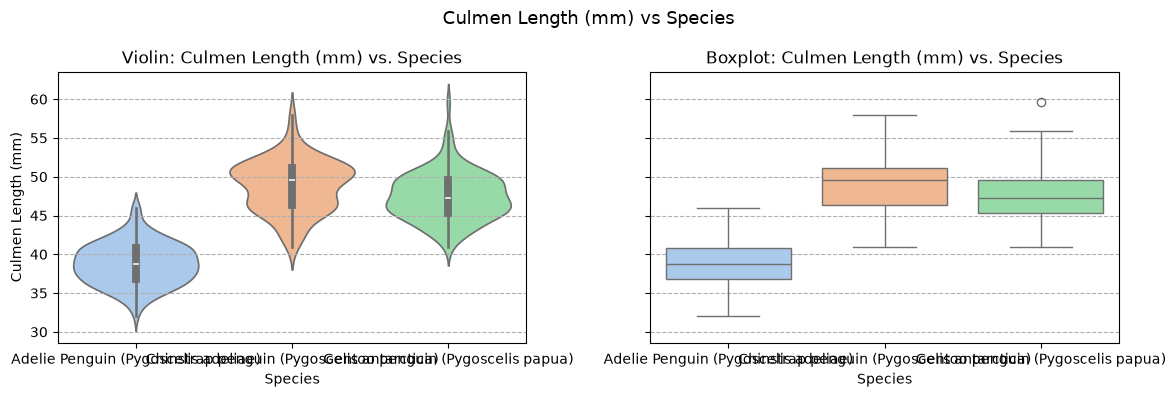

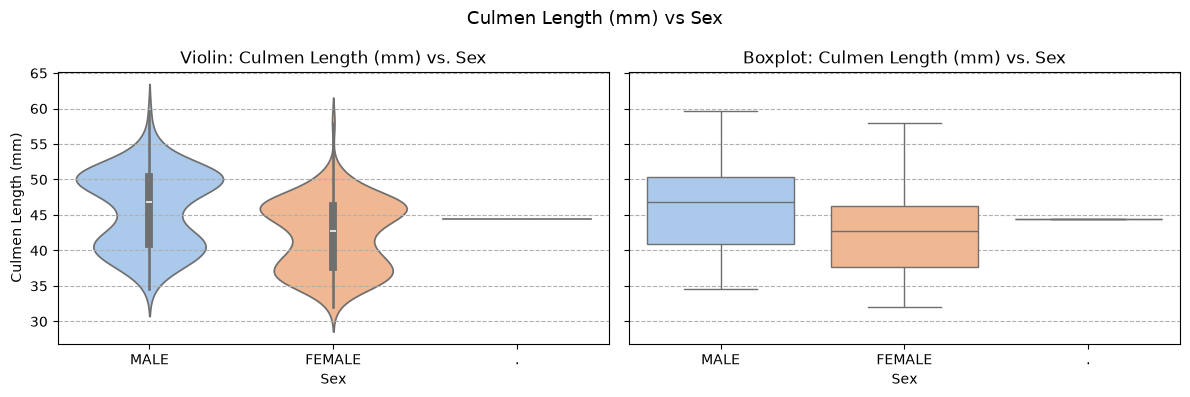

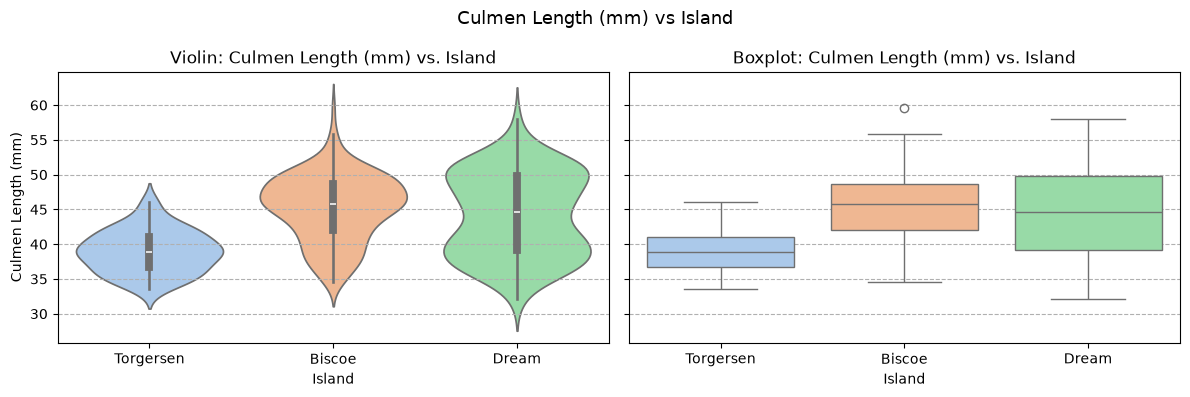

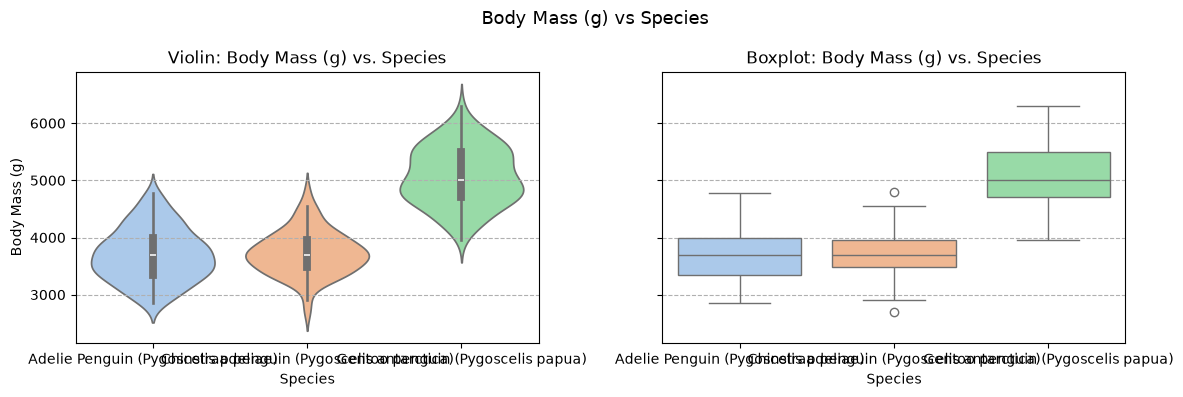

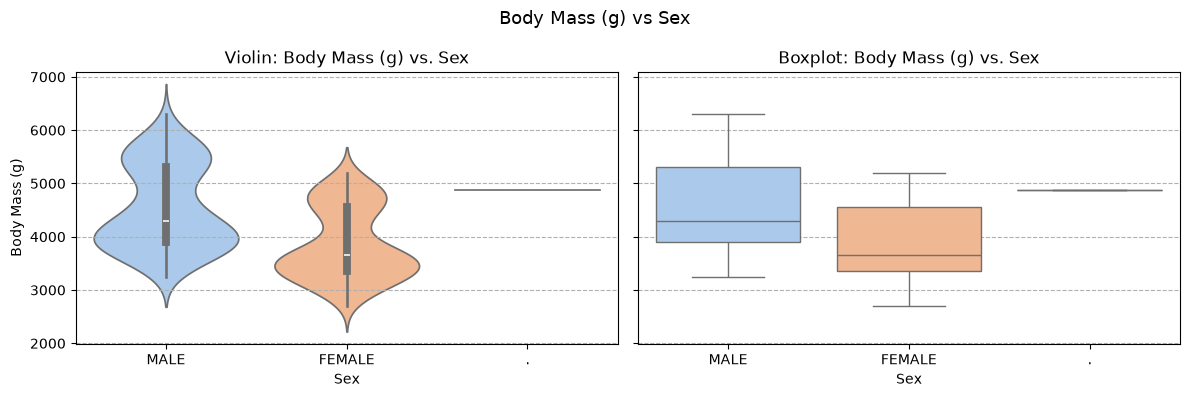

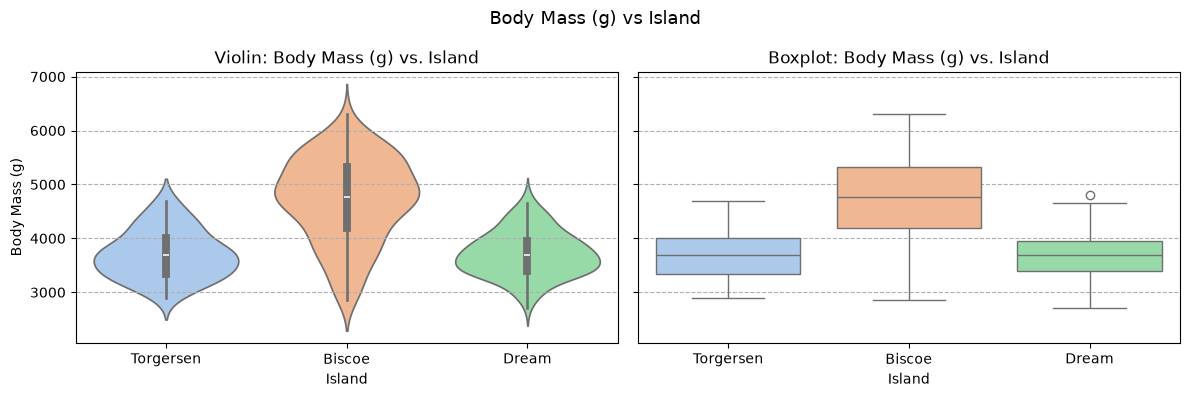

In [28]:
# Comparación de variables numéricas según diferentes categorías de los pingüinos
cat_cols = ['Species', 'Sex', 'Island']

for num in ['Culmen Length (mm)', 'Body Mass (g)']:
    for cat in cat_cols:
        plot_violin_box(penguins_df, num, cat)